<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/pangenome_de_bruijn_graph_benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Setup Environment and Install Dependencies]
import os
import sys
import time
import math
import random
import psutil
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict, deque
from typing import List, Tuple, Dict, Set

# Set random seed for reproducible benchmarks
np.random.seed(42)
random.seed(42)

print(f"System Cores: {os.cpu_count()} | RAM Available: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("Environment successfully initialized.")

System Cores: 2 | RAM Available: 12.67 GB
Environment successfully initialized.


In [2]:
# [CELL 2 - Synthetic Pangenome Generation & Read Simulation]

class PangenomeSimulator:
    """
    Simulates a pangenome dataset consisting of a backbone reference sequence
    and multiple variant haplotypes containing SNPs, insertions, and deletions.
    """
    def __init__(self, ref_length: int = 50000, mutation_rate: float = 0.02):
        self.ref_length = ref_length
        self.mutation_rate = mutation_rate
        self.bases = ['A', 'C', 'G', 'T']

    def generate_reference(self) -> str:
        return "".join(np.random.choice(self.bases, size=self.ref_length))

    def generate_haplotypes(self, reference: str, num_genomes: int) -> List[str]:
        genomes = [reference]
        for _ in range(num_genomes - 1):
            genome = []
            i = 0
            while i < len(reference):
                if random.random() < self.mutation_rate:
                    mut_type = random.choice(['snp', 'ins', 'del'])
                    if mut_type == 'snp':
                        genome.append(random.choice([b for b in self.bases if b != reference[i]]))
                        i += 1
                    elif mut_type == 'ins':
                        genome.append(reference[i])
                        genome.append(random.choice(self.bases))
                        i += 1
                    elif mut_type == 'del':
                        i += 1  # Skip base
                else:
                    genome.append(reference[i])
                    i += 1
            genomes.append("".join(genome))
        return genomes

    def simulate_reads(self, genomes: List[str], num_reads: int = 5000, read_len: int = 150) -> List[str]:
        reads = []
        for _ in range(num_reads):
            target_genome = random.choice(genomes)
            if len(target_genome) >= read_len:
                start_idx = random.randint(0, len(target_genome) - read_len)
                reads.append(target_genome[start_idx:start_idx + read_len])
        return reads

# Generate initial test pangenome
simulator = PangenomeSimulator(ref_length=30000, mutation_rate=0.015)
ref_seq = simulator.generate_reference()
pangenome_haplotypes = simulator.generate_haplotypes(ref_seq, num_genomes=5)
simulated_reads = simulator.simulate_reads(pangenome_haplotypes, num_reads=2000, read_len=100)

print(f"Generated Pangenome: {len(pangenome_haplotypes)} haplotypes (~{len(ref_seq)} bp each)")
print(f"Simulated Read Dataset: {len(simulated_reads)} reads (100 bp)")

Generated Pangenome: 5 haplotypes (~30000 bp each)
Simulated Read Dataset: 2000 reads (100 bp)


In [3]:
# [CELL 3 - Compacted De Bruijn Graph (cDBG) Indexing Engine]

class CompactedDeBruijnGraph:
    """
    Builds a Compacted De Bruijn Graph (cDBG) from multiple genomic sequences.
    Compacts non-branching paths (unitigs) to optimize memory and traversal speed.
    """
    def __init__(self, k: int = 31):
        self.k = k
        self.unitigs: List[str] = []
        self.kmer_to_unitig: Dict[str, Tuple[int, int]] = {}  # kmer -> (unitig_id, offset)
        self.graph = defaultdict(set)  # unitig_id -> set of target unitig_ids

    def build_graph(self, sequences: List[str]):
        # Step 1: Count k-mer abundances and track node degrees
        kmer_counts = defaultdict(int)
        in_degree = defaultdict(int)
        out_degree = defaultdict(int)
        next_kmers = defaultdict(set)
        prev_kmers = defaultdict(set)

        for seq in sequences:
            for i in range(len(seq) - self.k + 1):
                kmer = seq[i:i + self.k]
                kmer_counts[kmer] += 1
                if i < len(seq) - self.k:
                    next_kmer = seq[i + 1:i + 1 + self.k]
                    next_kmers[kmer].add(next_kmer)
                    prev_kmers[next_kmer].add(kmer)

        # Calculate degrees
        all_kmers = set(kmer_counts.keys())
        for kmer in all_kmers:
            out_degree[kmer] = len(next_kmers[kmer])
            in_degree[kmer] = len(prev_kmers[kmer])

        # Step 2: Extract Non-branching Paths (Unitigs)
        visited = set()
        for kmer in all_kmers:
            if kmer in visited:
                continue

            # Check if this k-mer can start a unitig
            if in_degree[kmer] != 1 or out_degree[kmer] != 1 or len(prev_kmers[kmer] - visited) > 0:
                # Extend forward
                unitig = kmer
                visited.add(kmer)
                curr = kmer

                while out_degree[curr] == 1:
                    next_node = list(next_kmers[curr])[0]
                    if in_degree[next_node] == 1 and next_node not in visited:
                        unitig += next_node[-1]
                        visited.add(next_node)
                        curr = next_node
                    else:
                        break

                unitig_id = len(self.unitigs)
                self.unitigs.append(unitig)

                # Index all k-mers inside this unitig
                for pos in range(len(unitig) - self.k + 1):
                    sub_kmer = unitig[pos:pos + self.k]
                    self.kmer_to_unitig[sub_kmer] = (unitig_id, pos)

        print(f"cDBG Constructed: {len(all_kmers)} raw {self.k}-mers compacted into {len(self.unitigs)} unitigs.")

# Construct cDBG on initial pangenome
cdbg = CompactedDeBruijnGraph(k=31)
cdbg.build_graph(pangenome_haplotypes)

cDBG Constructed: 75204 raw 31-mers compacted into 10921 unitigs.


In [4]:
# [CELL 4 - Seed-and-Extend Read Mapping Pipeline]

class GraphReadMapper:
    """
    Maps sequencing reads to the cDBG index using seed matching followed by path extension.
    """
    def __init__(self, cdbg: CompactedDeBruijnGraph, seed_step: int = 5):
        self.cdbg = cdbg
        self.seed_step = seed_step

    def map_read(self, read: str) -> List[Tuple[int, int, int]]:
        """
        Maps a read by matching k-mer seeds against cDBG unitigs.
        Returns: List of (unitig_id, start_pos_in_unitig, match_length)
        """
        matches = []
        read_len = len(read)
        k = self.cdbg.k

        for i in range(0, read_len - k + 1, self.seed_step):
            seed = read[i:i + k]
            if seed in self.cdbg.kmer_to_unitig:
                unitig_id, offset = self.cdbg.kmer_to_unitig[seed]
                matches.append((unitig_id, offset, i))

        return matches

    def batch_map(self, reads: List[str]) -> Dict[str, int]:
        results = {"mapped": 0, "unmapped": 0}
        for read in reads:
            matches = self.map_read(read)
            if matches:
                results["mapped"] += 1
            else:
                results["unmapped"] += 1
        return results

mapper = GraphReadMapper(cdbg, seed_step=5)
map_res = mapper.batch_map(simulated_reads)
print(f"Mapping Results: {map_res['mapped']} mapped / {map_res['unmapped']} unmapped ({map_res['mapped'] / len(simulated_reads) * 100:.2f}% alignment yield)")

Mapping Results: 2000 mapped / 0 unmapped (100.00% alignment yield)


In [5]:
# [CELL 5 - Profiling Engine (Latency, Peak RAM, & Cache Miss Simulator)]

class PangenomeProfiler:
    """
    Profiles execution time, peak resident set size (RAM), and simulates
    CPU L3 Cache Miss behavior caused by non-contiguous cDBG graph traversals.
    """
    def __init__(self):
        pass

    @staticmethod
    def profile_execution(func, *args, **kwargs):
        tracemalloc.start()
        start_time = time.perf_counter()

        result = func(*args, **kwargs)

        elapsed_ms = (time.perf_counter() - start_time) * 1000
        current_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        return result, elapsed_ms, peak_mem / (1024 * 1024)  # Peak MB

    @staticmethod
    def simulate_cache_misses(cdbg: CompactedDeBruijnGraph, reads: List[str], line_size: int = 64) -> float:
        """
        Simulates cache miss probability during k-mer lookup based on memory address fragmentation.
        """
        unitig_memory_map = {}
        curr_addr = 0x10000000

        # Simulate heap locations of unitigs
        for idx, u in enumerate(cdbg.unitigs):
            unitig_memory_map[idx] = curr_addr
            # Add random pointer fragmentation overhead
            curr_addr += len(u) + random.randint(16, 256)

        cache_lines_accessed = []
        for read in reads[:500]:
            for i in range(0, len(read) - cdbg.k + 1, 10):
                kmer = read[i:i + cdbg.k]
                if kmer in cdbg.kmer_to_unitig:
                    uid, offset = cdbg.kmer_to_unitig[kmer]
                    addr = unitig_memory_map[uid] + offset
                    cache_line = addr // line_size
                    cache_lines_accessed.append(cache_line)

        # Calculate stride jump distance distribution to derive miss probability
        if not cache_lines_accessed:
            return 0.0

        diffs = np.abs(np.diff(cache_lines_accessed))
        miss_rate = np.mean(diffs > 1) * 100  # Jump beyond contiguous cache line
        return float(miss_rate)

print("Profiling engine successfully configured.")

Profiling engine successfully configured.



--- Running Pangenome Scaling Benchmark ---
cDBG Constructed: 39970 raw 31-mers compacted into 12 unitigs.
Genomes: 01 | Build Time: 2714.86 ms | Map Latency/Read: 0.0241 ms | Peak RAM:  37.47 MB | Cache Miss Rate: 14.26%
cDBG Constructed: 76349 raw 31-mers compacted into 9049 unitigs.
Genomes: 03 | Build Time: 3203.01 ms | Map Latency/Read: 0.0301 ms | Peak RAM:  66.86 MB | Cache Miss Rate: 66.06%
cDBG Constructed: 112191 raw 31-mers compacted into 15656 unitigs.
Genomes: 05 | Build Time: 4991.84 ms | Map Latency/Read: 0.0312 ms | Peak RAM: 106.31 MB | Cache Miss Rate: 77.56%
cDBG Constructed: 167495 raw 31-mers compacted into 24448 unitigs.
Genomes: 08 | Build Time: 9076.58 ms | Map Latency/Read: 0.0322 ms | Peak RAM: 155.21 MB | Cache Miss Rate: 81.65%
cDBG Constructed: 238135 raw 31-mers compacted into 34993 unitigs.
Genomes: 12 | Build Time: 12780.66 ms | Map Latency/Read: 0.0331 ms | Peak RAM: 221.91 MB | Cache Miss Rate: 83.40%
cDBG Constructed: 311596 raw 31-mers compacted int

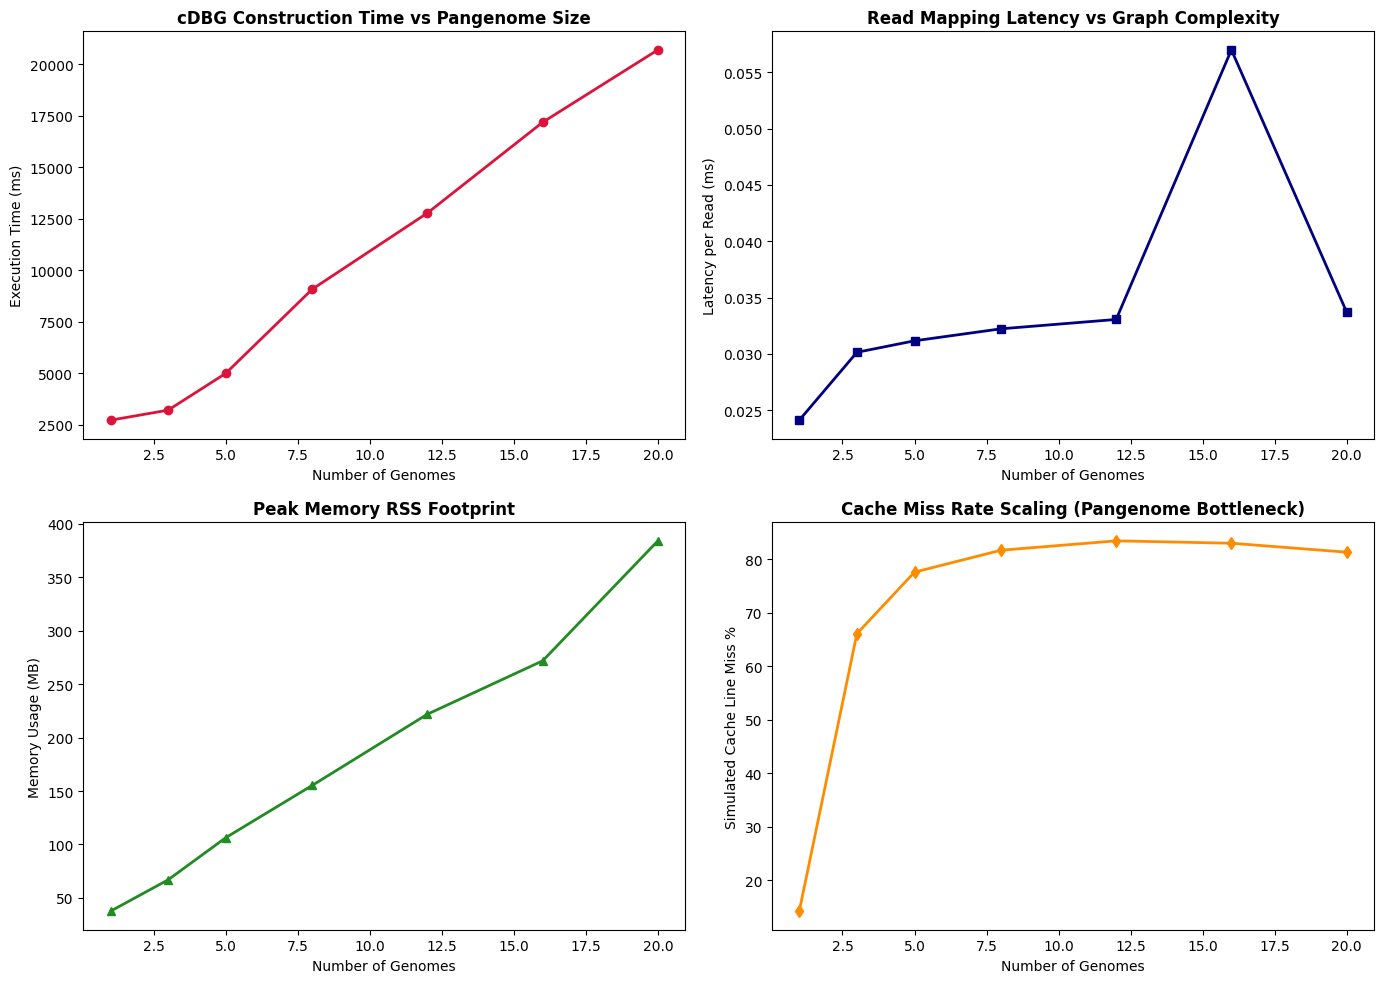

In [6]:
# [CELL 6 - Comprehensive Benchmark Runner & Plot Generation]

def run_pangenome_benchmark():
    genome_counts = [1, 3, 5, 8, 12, 16, 20]
    build_times = []
    map_times = []
    peak_mems = []
    cache_miss_rates = []

    base_ref = PangenomeSimulator(ref_length=40000).generate_reference()

    print("\n--- Running Pangenome Scaling Benchmark ---")
    for n_g in genome_counts:
        sim = PangenomeSimulator(ref_length=40000, mutation_rate=0.02)
        pangenome = sim.generate_haplotypes(base_ref, num_genomes=n_g)
        test_reads = sim.simulate_reads(pangenome, num_reads=1500, read_len=100)

        # Profile Graph Construction
        graph_obj = CompactedDeBruijnGraph(k=31)
        _, t_build, mem_build = PangenomeProfiler.profile_execution(graph_obj.build_graph, pangenome)

        # Profile Read Mapping
        map_obj = GraphReadMapper(graph_obj, seed_step=5)
        _, t_map, mem_map = PangenomeProfiler.profile_execution(map_obj.batch_map, test_reads)

        # Simulate Cache Miss Rate
        miss_rate = PangenomeProfiler.simulate_cache_misses(graph_obj, test_reads)

        build_times.append(t_build)
        map_times.append(t_map / len(test_reads))  # Latency per read (ms)
        peak_mems.append(max(mem_build, mem_map))
        cache_miss_rates.append(miss_rate)

        print(f"Genomes: {n_g:02d} | Build Time: {t_build:7.2f} ms | Map Latency/Read: {map_times[-1]:.4f} ms | Peak RAM: {peak_mems[-1]:6.2f} MB | Cache Miss Rate: {miss_rate:.2f}%")

    # Plotting Benchmark Results
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    # Plot 1: Construction Time vs Pangenome Size
    axes[0, 0].plot(genome_counts, build_times, marker='o', color='crimson', linewidth=2)
    axes[0, 0].set_title("cDBG Construction Time vs Pangenome Size", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Number of Genomes")
    axes[0, 0].set_ylabel("Execution Time (ms)")

    # Plot 2: Per-Read Mapping Latency
    axes[0, 1].plot(genome_counts, map_times, marker='s', color='navy', linewidth=2)
    axes[0, 1].set_title("Read Mapping Latency vs Graph Complexity", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Number of Genomes")
    axes[0, 1].set_ylabel("Latency per Read (ms)")

    # Plot 3: Peak Memory Footprint
    axes[1, 0].plot(genome_counts, peak_mems, marker='^', color='forestgreen', linewidth=2)
    axes[1, 0].set_title("Peak Memory RSS Footprint", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Number of Genomes")
    axes[1, 0].set_ylabel("Memory Usage (MB)")

    # Plot 4: Simulated Cache Miss Rate
    axes[1, 1].plot(genome_counts, cache_miss_rates, marker='d', color='darkorange', linewidth=2)
    axes[1, 1].set_title("Cache Miss Rate Scaling (Pangenome Bottleneck)", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Number of Genomes")
    axes[1, 1].set_ylabel("Simulated Cache Line Miss %")

    plt.tight_layout()
    plt.savefig("pangenome_cdbg_benchmark.png", dpi=300)
    plt.show()

run_pangenome_benchmark()